# Chapter 17: Valves and Flow Control

This notebook demonstrates valve modeling and flow control analysis using
NeqSim's `ThrottlingValve` class. We examine Cv-based valve sizing,
pressure drop characteristics, Joule–Thomson cooling, and the effect
of valve opening on flow control.

**Key concepts:**
- Cv / Kv valve sizing per IEC 60534
- Pressure drop vs. flow rate characteristic
- Joule–Thomson (JT) cooling effect through valves
- Valve opening control and turndown

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch15_valves_flow_control.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


## 17.1 Define Feed Stream and Throttling Valve

We set up a natural gas stream at high pressure and throttle it through
a control valve with a specified outlet pressure.

In [2]:
# jneqsim is bound to the source JVM in the setup cell.

Stream = jneqsim.process.equipment.stream.Stream
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

# Create natural gas fluid
fluid = jneqsim.thermo.system.SystemSrkEos(273.15 + 50.0, 150.0)
fluid.addComponent("methane", 0.85)
fluid.addComponent("ethane", 0.07)
fluid.addComponent("propane", 0.04)
fluid.addComponent("n-butane", 0.02)
fluid.addComponent("CO2", 0.015)
fluid.addComponent("nitrogen", 0.005)
fluid.setMixingRule("classic")

# Feed stream
feed = Stream("HP Gas", fluid)
feed.setFlowRate(50000.0, "kg/hr")
feed.setTemperature(50.0, "C")
feed.setPressure(150.0, "bara")

# Throttling valve
valve = ThrottlingValve("Choke Valve", feed)
valve.setOutletPressure(80.0, "bara")

# Build and run process
process = ProcessSystem()
process.add(feed)
process.add(valve)
process.run()

T_in = feed.getTemperature("C")
T_out = valve.getOutletStream().getTemperature("C")
P_in = feed.getPressure("bara")
P_out = valve.getOutletStream().getPressure("bara")
dP = valve.getDeltaPressure("bara")
Cv = valve.getCv("US")

print(f"Inlet:    {T_in:.1f} °C,  {P_in:.0f} bara")
print(f"Outlet:   {T_out:.1f} °C,  {P_out:.0f} bara")
print(f"ΔP:       {dP:.1f} bar")
print(f"JT cooling: {T_in - T_out:.1f} °C")
print(f"Cv (US):  {Cv:.1f}")

Inlet:    50.0 °C,  150 bara
Outlet:   27.0 °C,  80 bara
ΔP:       70.0 bar
JT cooling: 23.0 °C
Cv (US):  28.3


## 17.2 Pressure Drop vs. Flow Rate

At fixed inlet and outlet pressures, we vary the mass flow rate to observe
how the required Cv changes and how JT cooling varies.

Figure saved: ch15_cv_and_jt_vs_flow.png


ch15_valves_flow_control.ipynb:cell5:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


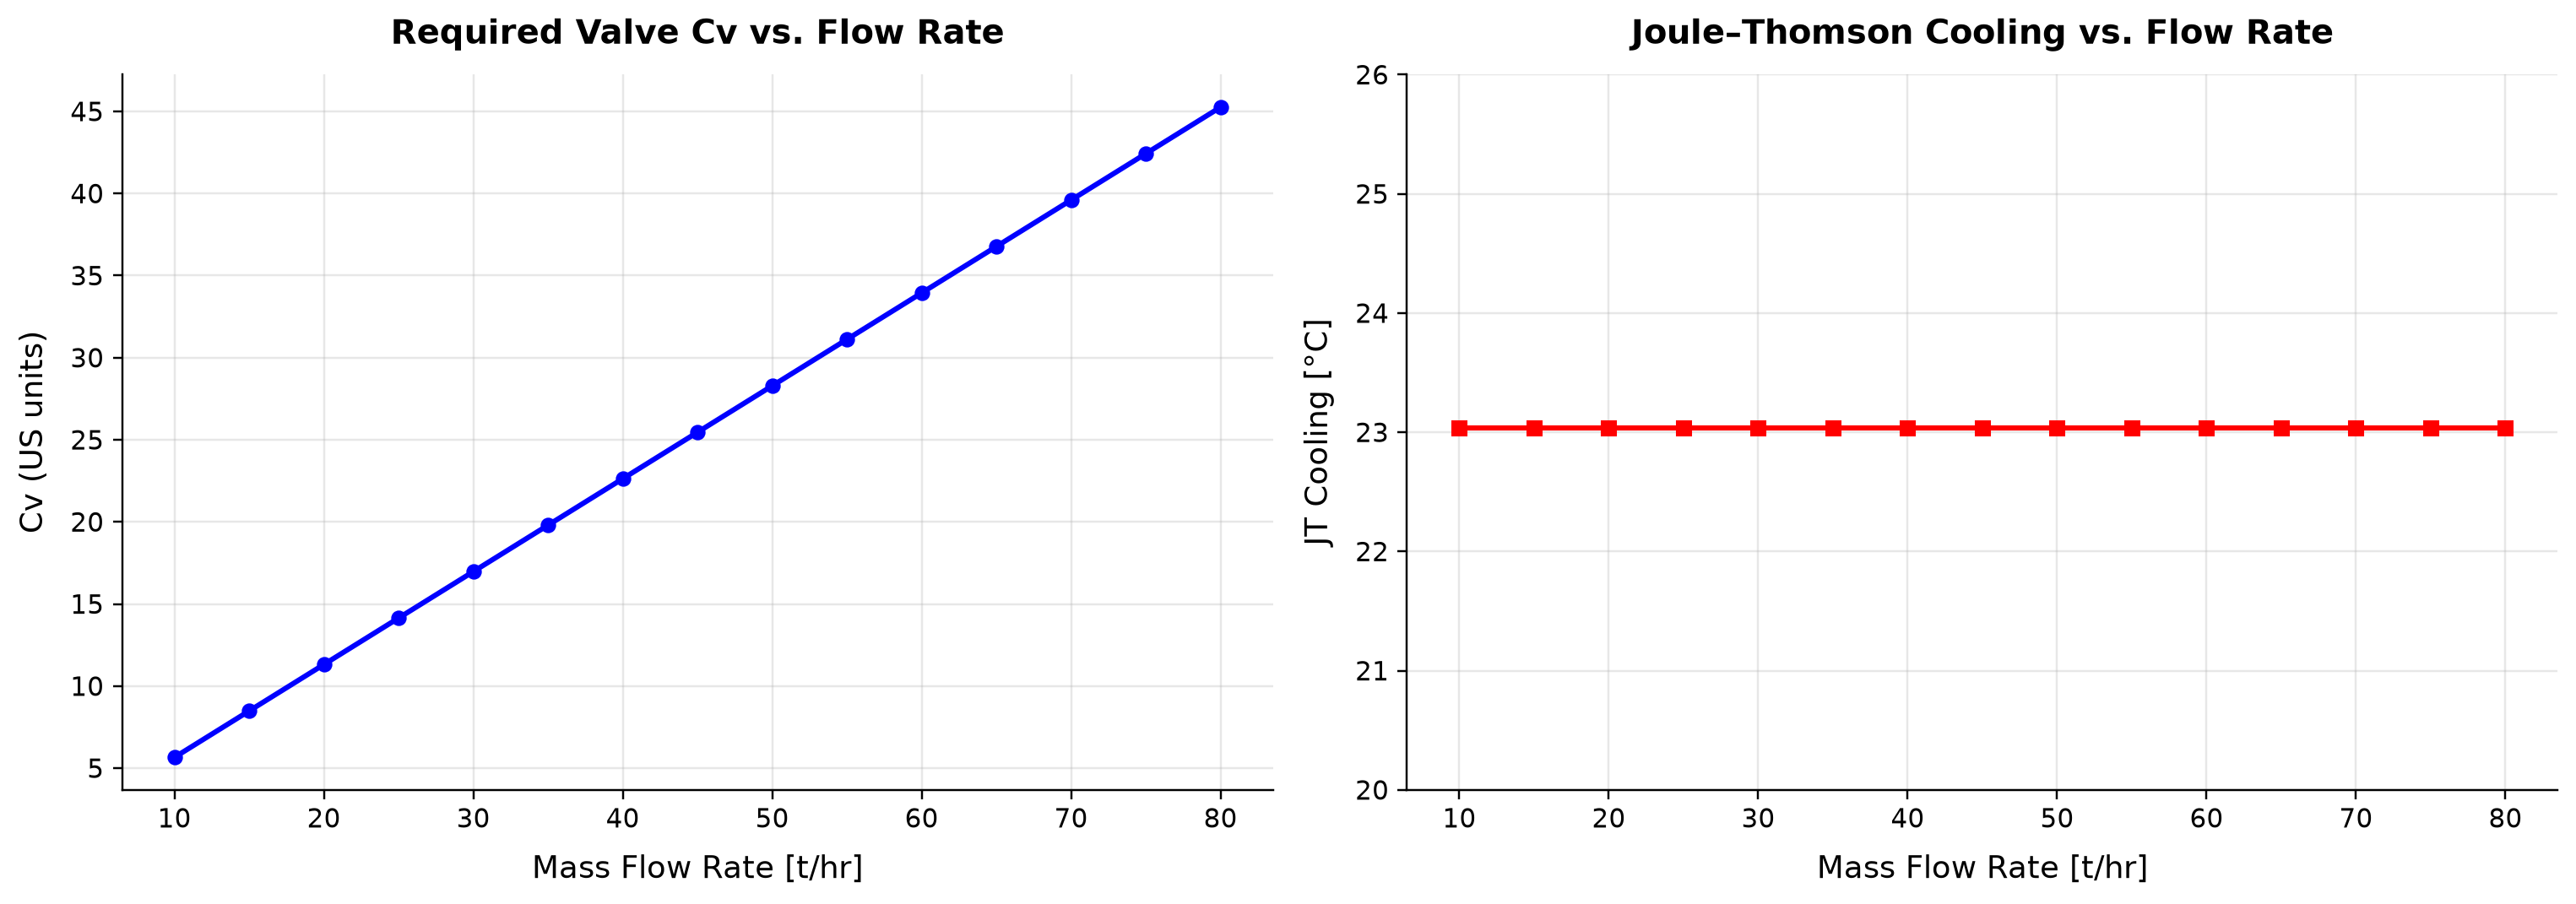

In [3]:
flow_rates = np.linspace(10000, 80000, 15)  # kg/hr
cv_values = []
jt_cooling = []
outlet_temps = []

for flow in flow_rates:
    feed.setFlowRate(float(flow), "kg/hr")
    feed.run()
    sized_valve = ThrottlingValve("Independently sized valve", feed)
    sized_valve.setOutletPressure(80.0, "bara")
    sized_valve.run()
    cv_values.append(sized_valve.getCv("US"))
    T_out_i = sized_valve.getOutletStream().getTemperature("C")
    outlet_temps.append(T_out_i)
    jt_cooling.append(T_in - T_out_i)

assert cv_values[-1] > 7.9 * cv_values[0], "Required Cv must scale with rate at fixed states"

# Reset
feed.setFlowRate(50000.0, "kg/hr")
process.run()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(flow_rates / 1000, cv_values, 'b-o', linewidth=2, markersize=5)
ax1.set_xlabel('Mass Flow Rate [t/hr]', fontsize=12)
ax1.set_ylabel('Cv (US units)', fontsize=12)
ax1.set_title('Required Valve Cv vs. Flow Rate', fontsize=13)
ax1.grid(True, alpha=0.3)

ax2.plot(flow_rates / 1000, jt_cooling, 'r-s', linewidth=2, markersize=5)
ax2.set_xlabel('Mass Flow Rate [t/hr]', fontsize=12)
ax2.set_ylim(20.0, 26.0)  # show constant JT cooling on an engineering scale
ax2.set_ylabel('JT Cooling [°C]', fontsize=12)
ax2.set_title('Joule–Thomson Cooling vs. Flow Rate', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch15_cv_and_jt_vs_flow.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ch15_cv_and_jt_vs_flow.png")

**Executed-figure discussion.** Cv spans 5.657–45.26 US units across the plotted cases. JT Cooling remains 23.04 °C across the plotted cases.

At fixed upstream and downstream states, increasing flow requires a larger valve capacity; the isenthalpic temperature change can remain almost independent of flow. Reusing an already sized valve can conceal the required-Cv trend, while constant JT cooling is physically plausible for identical inlet states and pressure drop. Size a fresh valve or clear its sizing state for each trial, then select hardware with rangeability and controllability across the full flow envelope.


## 17.3 JT Cooling Across Different Pressure Drops

We fix the flow rate and vary the valve outlet pressure to map the
relationship between pressure drop and temperature drop (JT effect).

Figure saved: ch15_jt_cooling_vs_dp.png


ch15_valves_flow_control.ipynb:cell7:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


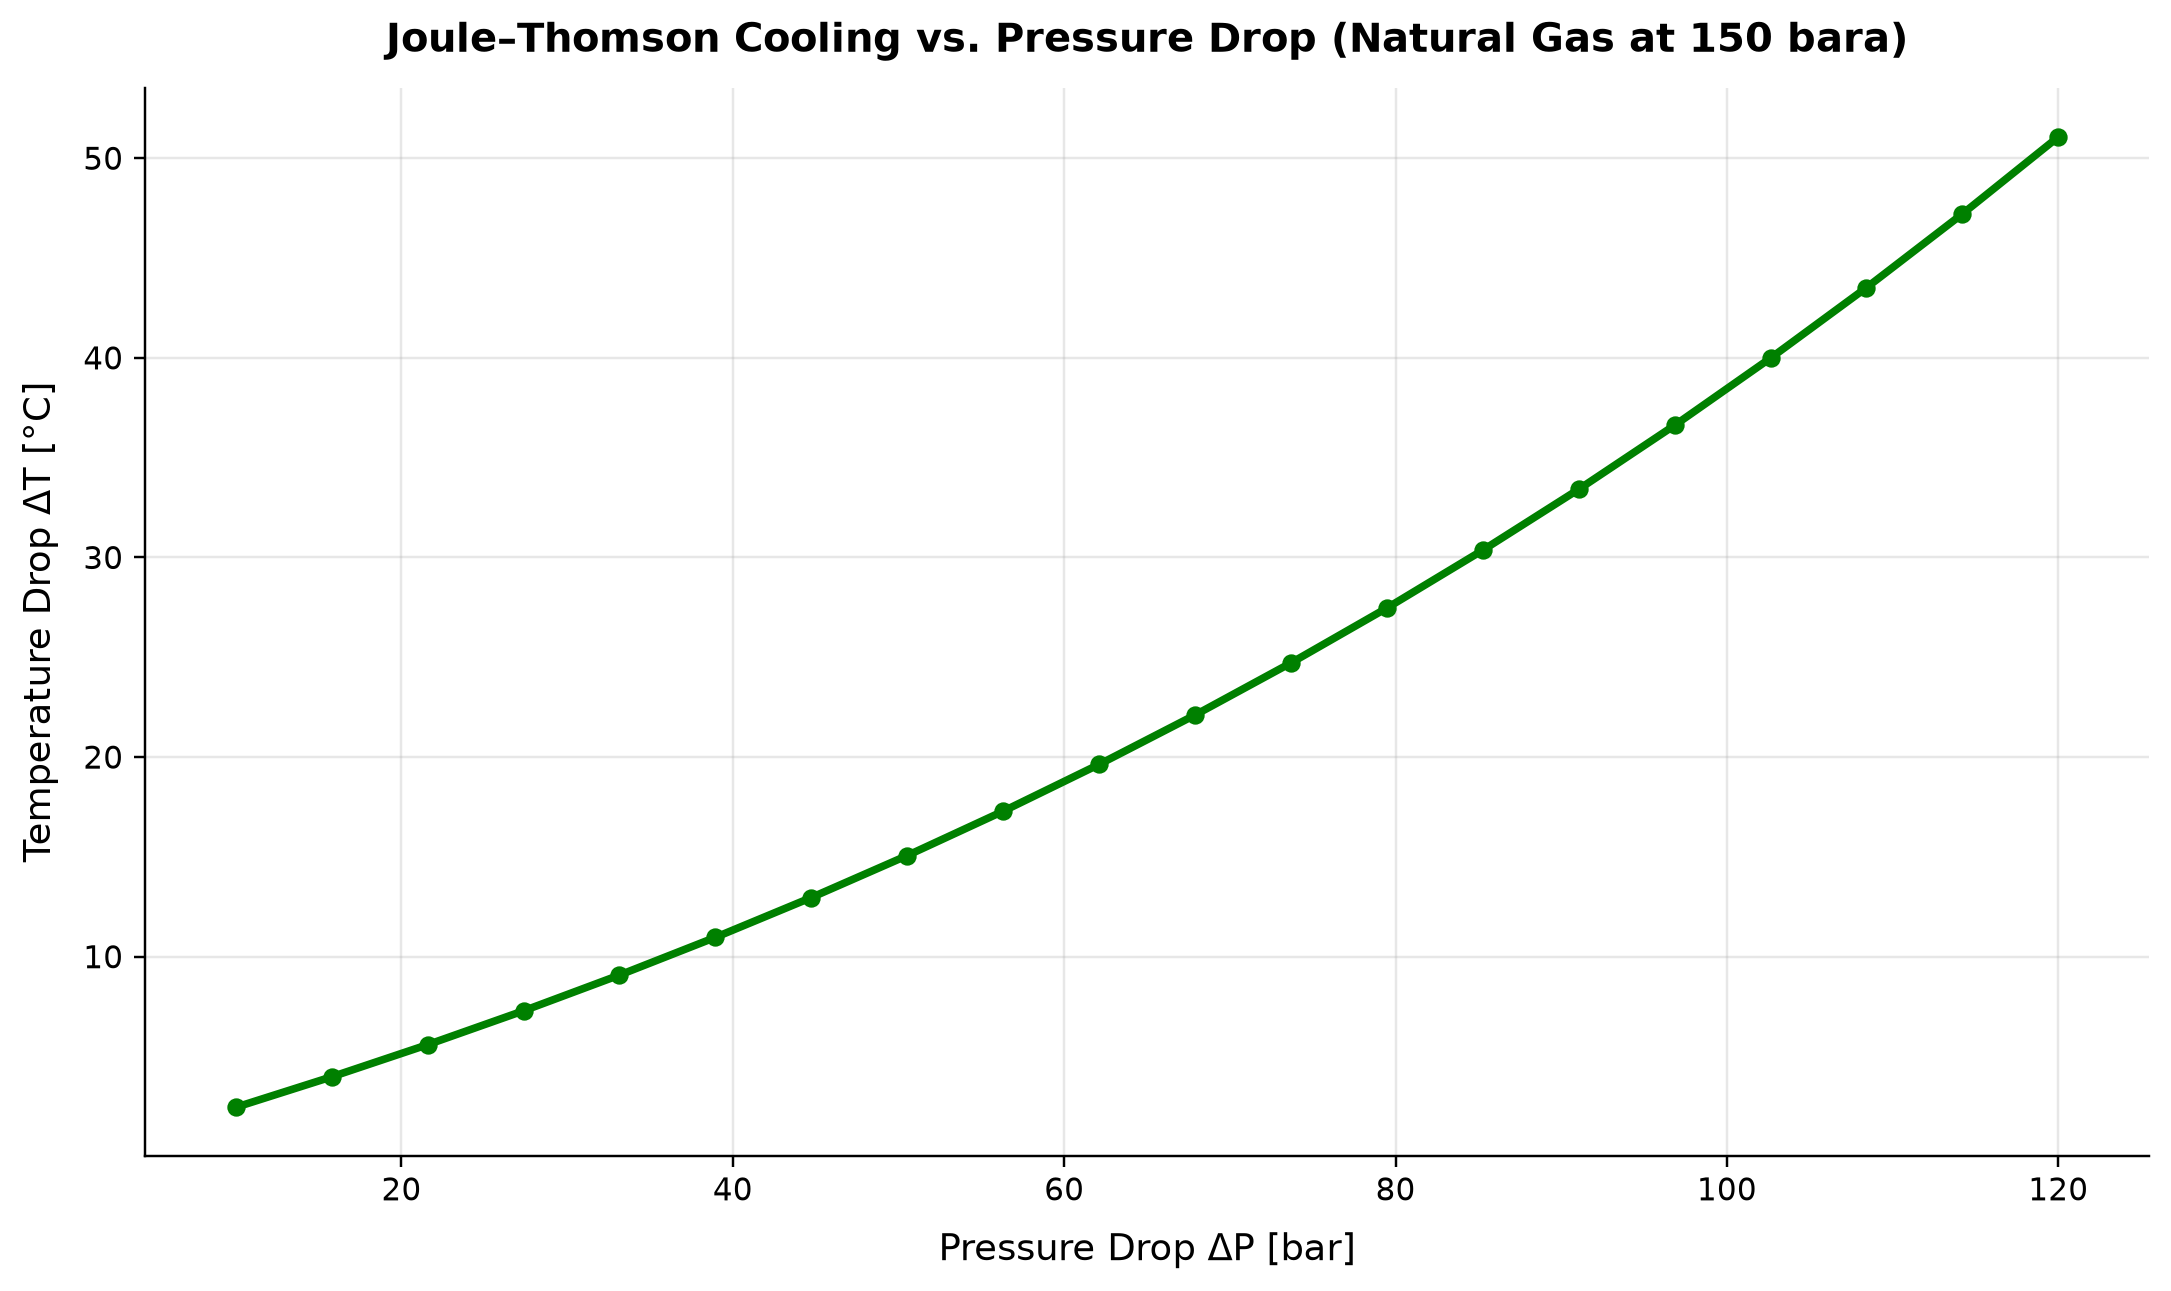

In [4]:
outlet_pressures = np.linspace(30.0, 140.0, 20)
delta_T = []
delta_P = []

for p_out in outlet_pressures:
    valve.setOutletPressure(float(p_out), "bara")
    process.run()
    T_outlet = valve.getOutletStream().getTemperature("C")
    delta_T.append(T_in - T_outlet)
    delta_P.append(P_in - float(p_out))

# Reset
valve.setOutletPressure(80.0, "bara")
process.run()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(delta_P, delta_T, 'g-o', linewidth=2.5, markersize=5)
ax.set_xlabel('Pressure Drop ΔP [bar]', fontsize=12)
ax.set_ylabel('Temperature Drop ΔT [°C]', fontsize=12)
ax.set_title('Joule–Thomson Cooling vs. Pressure Drop (Natural Gas at 150 bara)', fontsize=13)
ax.grid(True, alpha=0.3)

# Annotate approximate JT coefficient
if len(delta_P) > 2 and delta_P[-1] > delta_P[0]:
    jt_coeff = (delta_T[-1] - delta_T[0]) / (delta_P[-1] - delta_P[0])
    ax.annotate(f'Avg. JT coeff ≈ {jt_coeff:.2f} °C/bar',
                xy=(delta_P[len(delta_P)//2], delta_T[len(delta_T)//2]),
                fontsize=11, fontweight='bold',
                xytext=(20, 20), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch15_jt_cooling_vs_dp.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ch15_jt_cooling_vs_dp.png")

**Executed-figure discussion.** Temperature Drop ΔT spans 2.455–51.07 °C across the plotted cases.

A larger isenthalpic pressure reduction usually produces more cooling for the illustrated natural-gas state, with nonlinearity from changing fluid properties. The coldest valve outlet can determine hydrate, low-temperature material and downstream separation requirements. Calculate the full PH-flash path and check cold-start and low-flow inlet conditions rather than relying on a constant JT coefficient.


## 17.4 Pressure and Temperature Profiles Through the Valve

We summarize the inlet and outlet conditions and visualize the
pressure-temperature path through the throttling process.

Figure saved: ch15_pt_path.png


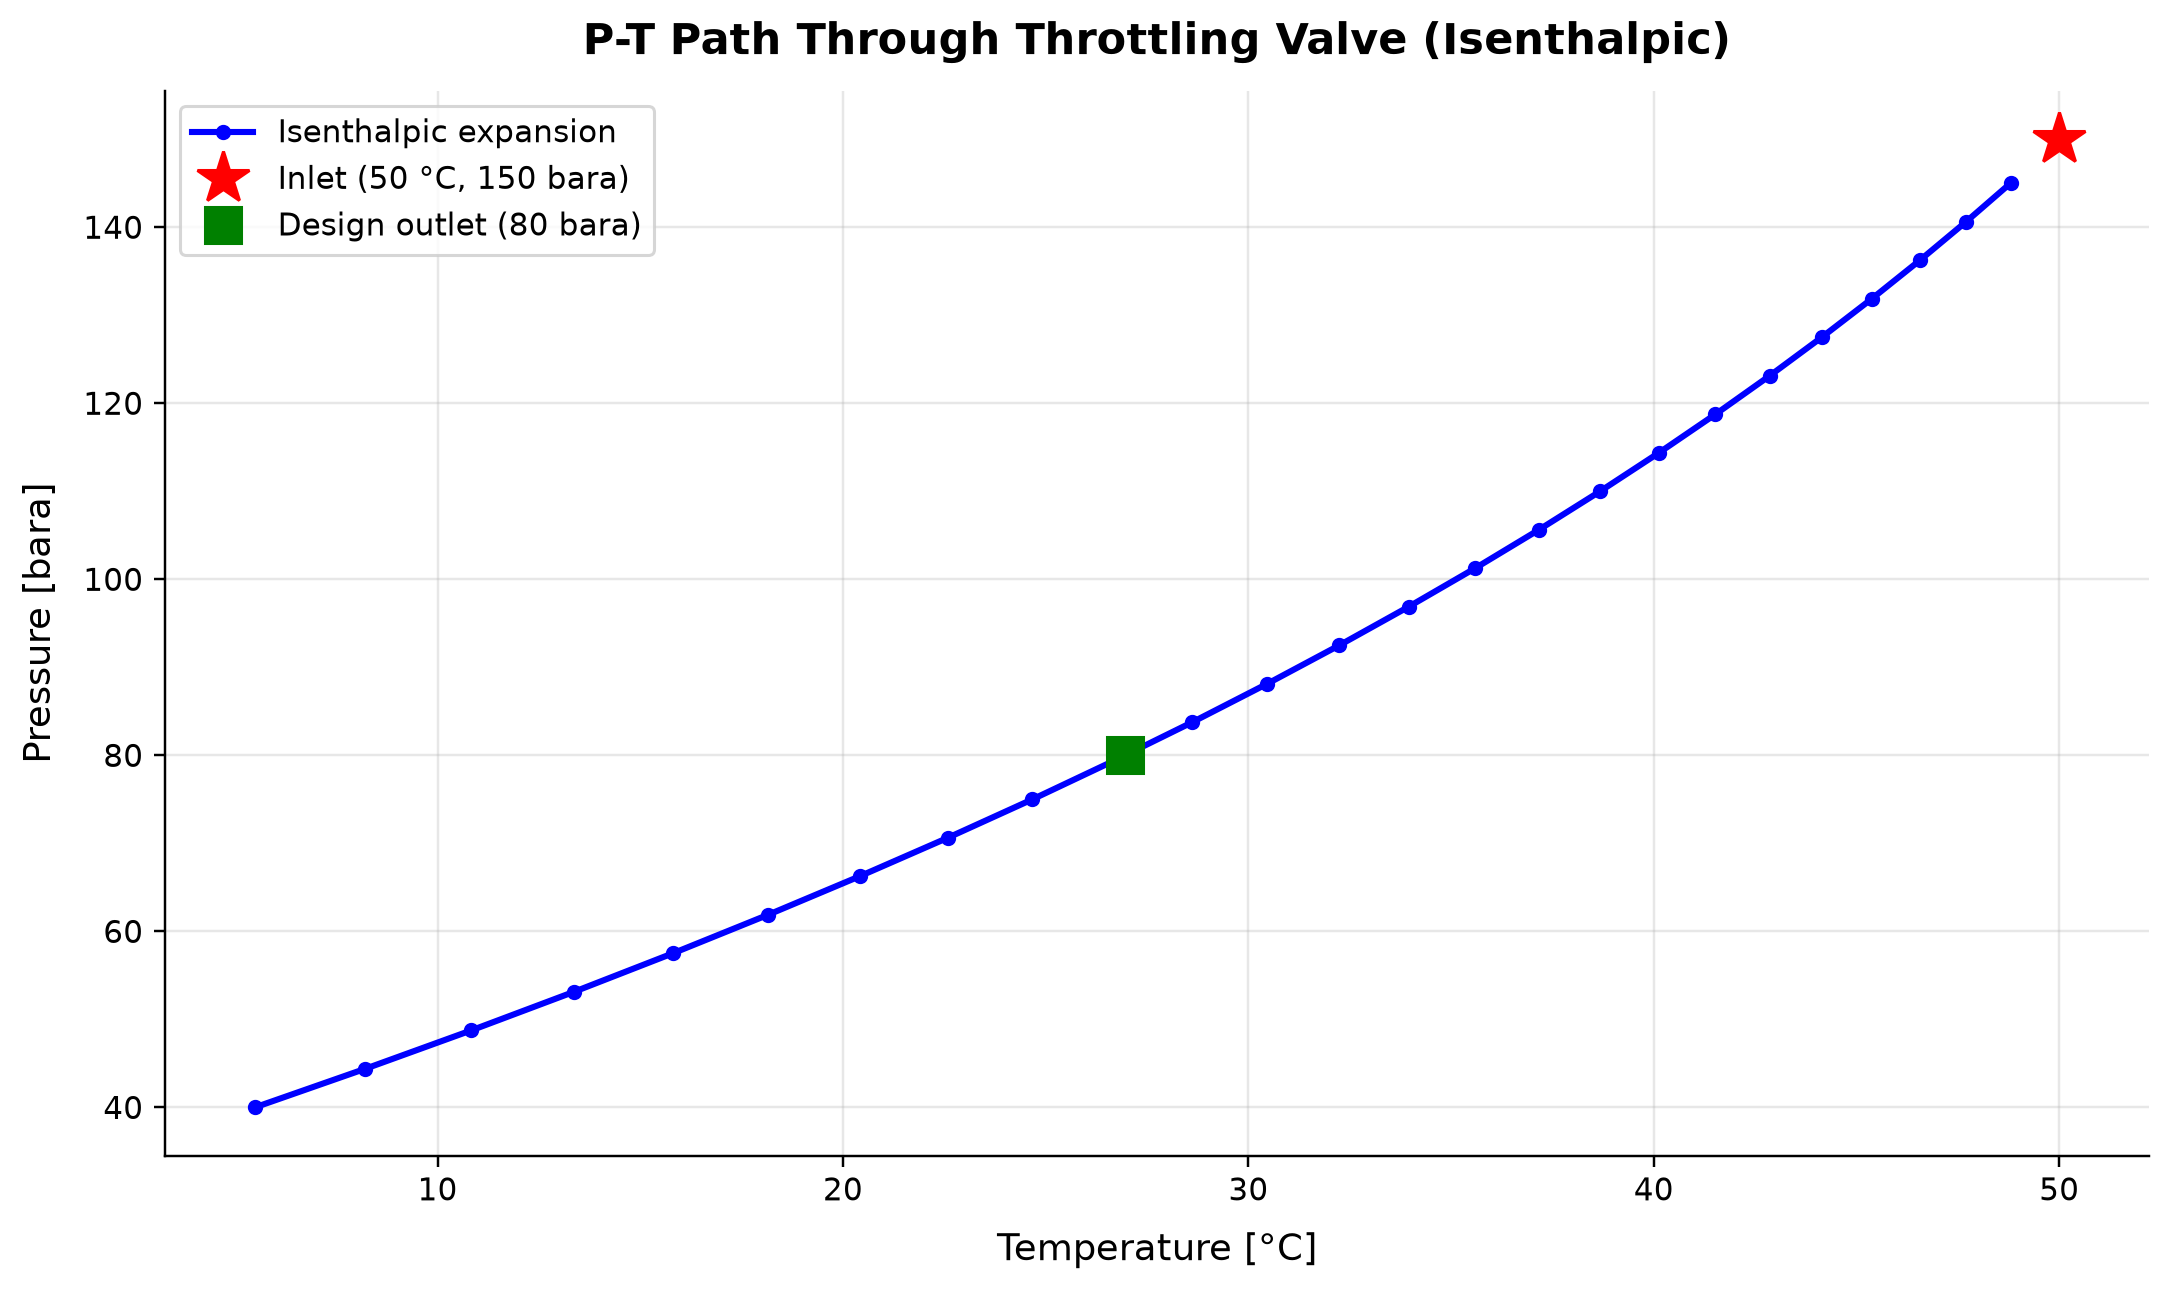

In [5]:
# Compute the P-T path through the valve for several outlet pressures
p_out_range = np.linspace(40.0, 145.0, 25)
T_path = []
P_path = []

for p_out in p_out_range:
    valve.setOutletPressure(float(p_out), "bara")
    process.run()
    T_path.append(valve.getOutletStream().getTemperature("C"))
    P_path.append(float(p_out))

# Reset
valve.setOutletPressure(80.0, "bara")
process.run()

fig, ax = plt.subplots(figsize=(10, 6))

# Plot P-T path
ax.plot(T_path, P_path, 'b-o', linewidth=2, markersize=4, label='Isenthalpic expansion')
ax.plot(T_in, P_in, 'r*', markersize=18, zorder=5, label=f'Inlet ({T_in:.0f} °C, {P_in:.0f} bara)')

# Mark design outlet
ax.plot(valve.getOutletStream().getTemperature("C"), 80.0, 'gs', markersize=12, zorder=5,
        label=f'Design outlet (80 bara)')

ax.set_xlabel('Temperature [°C]', fontsize=12)
ax.set_ylabel('Pressure [bara]', fontsize=12)
ax.set_title('P-T Path Through Throttling Valve (Isenthalpic)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch15_pt_path.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ch15_pt_path.png")

**Executed-figure discussion.** Isenthalpic expansion: pressure spans 40–145 bara across the plotted cases.

The pressure–temperature path follows constant stream enthalpy through an adiabatic valve rather than an isothermal or isentropic expansion. Crossing saturation or hydrate boundaries can change the downstream phase load and operating risk even when pressure control is achieved. Overlay the relevant phase and hydrate boundaries for the actual composition and evaluate the required temperature and pressure margins.


## 17.5 Valve Opening and Cv Relationship

We examine how effective Cv changes with valve percent opening,
demonstrating valve rangeability and control characteristics.

Figure saved: ch15_valve_opening.png


ch15_valves_flow_control.ipynb:cell11:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


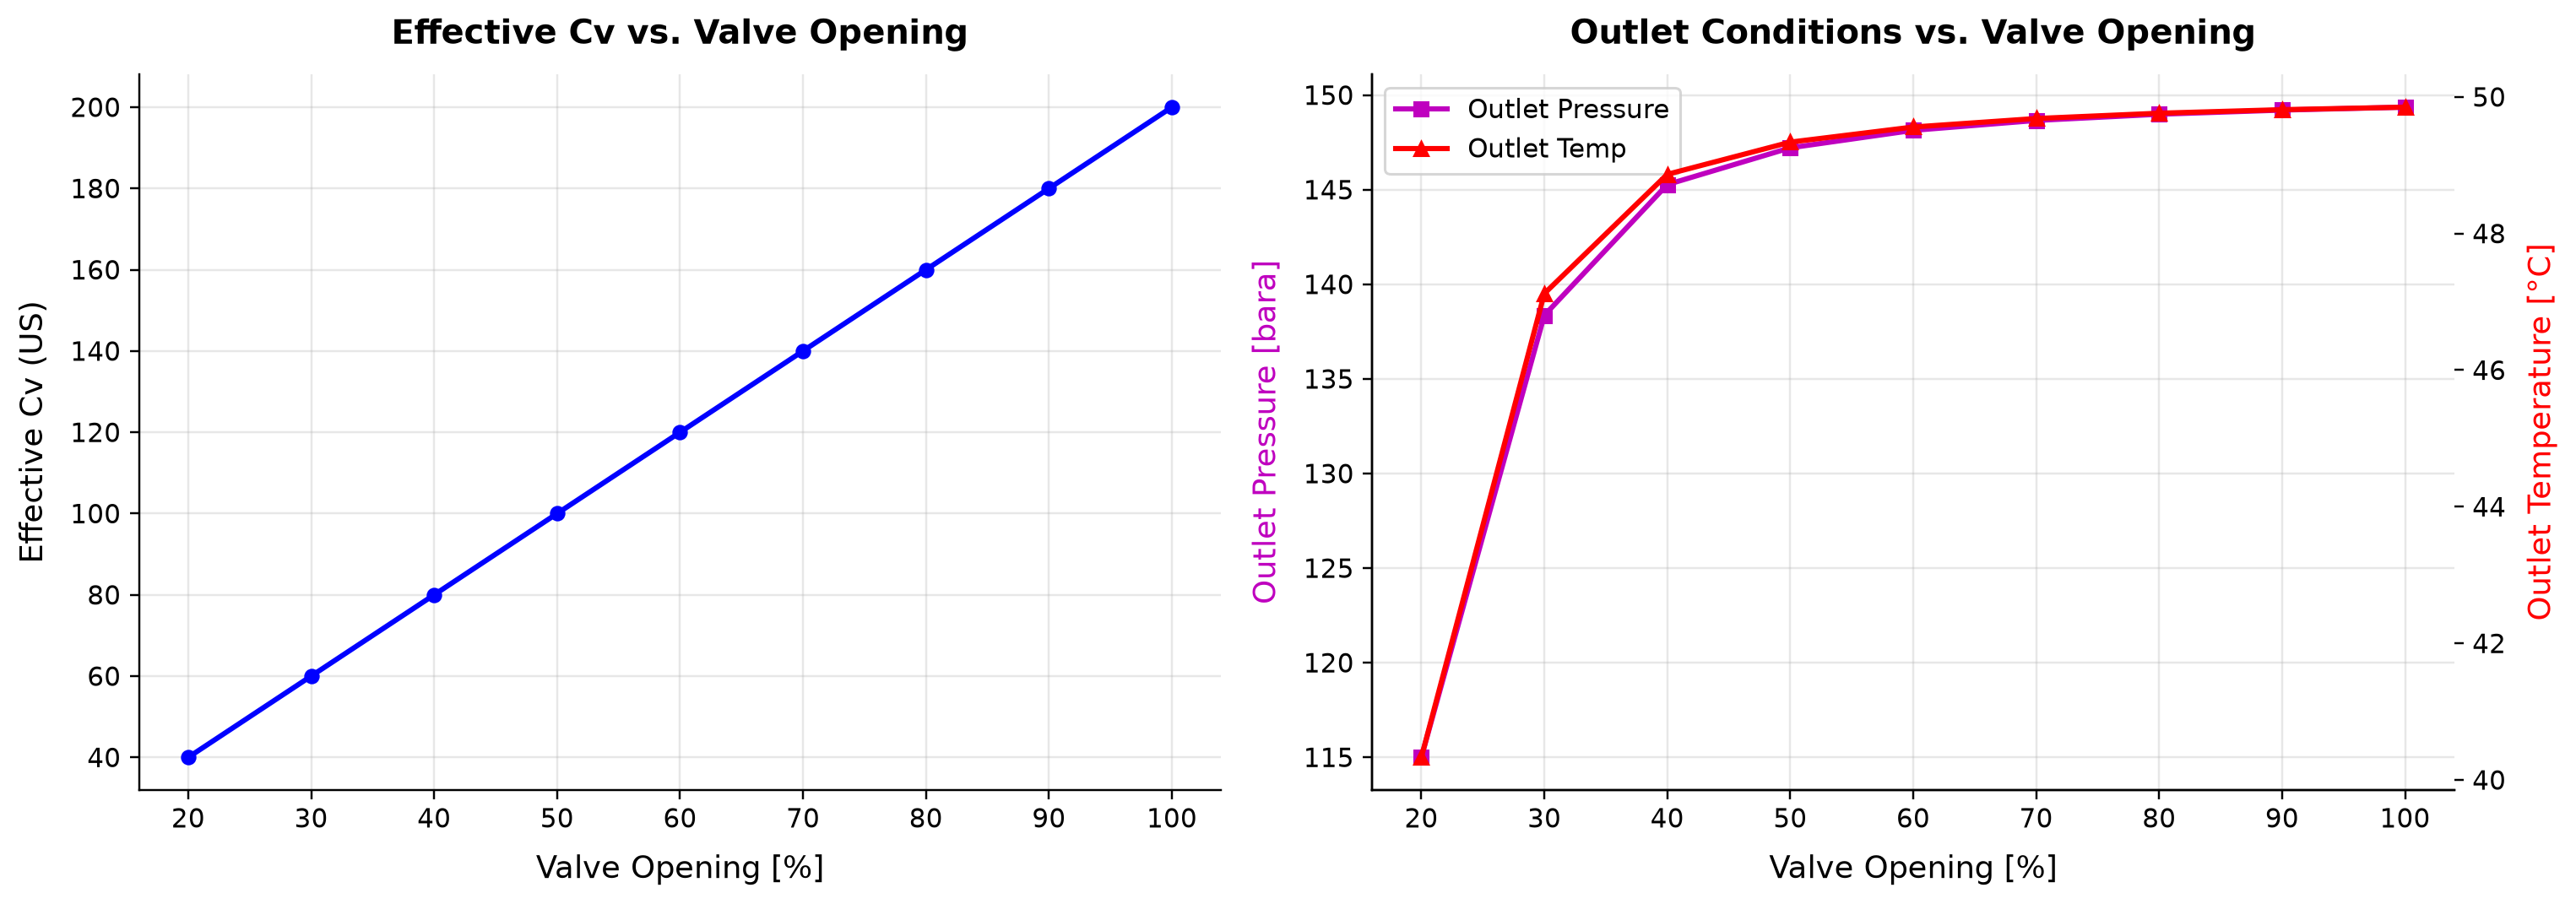

In [6]:
# Set a known Cv for the valve
valve.setCv(200.0, "US")

valve.setIsCalcOutPressure(True)
openings = np.linspace(20, 100, 9)
effective_cv = []
outlet_T = []
outlet_P = []

for opening in openings:
    valve.setPercentValveOpening(float(opening))
    process.run()
    effective_cv.append(valve.getCv("US") * float(opening) / 100.0)  # effective Cv
    outlet_T.append(valve.getOutletStream().getTemperature("C"))
    pressure = float(valve.getOutletStream().getPressure("bara"))
    assert 0.0 < pressure <= P_in, "Valve cannot increase pressure"
    outlet_P.append(pressure)

# Reset
valve.setIsCalcOutPressure(False)
valve.setPercentValveOpening(100.0)
valve.setOutletPressure(80.0, "bara")
process.run()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(openings, effective_cv, 'b-o', linewidth=2, markersize=5)
ax1.set_xlabel('Valve Opening [%]', fontsize=12)
ax1.set_ylabel('Effective Cv (US)', fontsize=12)
ax1.set_title('Effective Cv vs. Valve Opening', fontsize=13)
ax1.grid(True, alpha=0.3)

ax2.plot(openings, outlet_P, 'm-s', linewidth=2, markersize=5, label='Outlet Pressure')
ax2_twin = ax2.twinx()
ax2_twin.plot(openings, outlet_T, 'r-^', linewidth=2, markersize=5, label='Outlet Temp')

ax2.set_xlabel('Valve Opening [%]', fontsize=12)
ax2.set_ylabel('Outlet Pressure [bara]', fontsize=12, color='m')
ax2_twin.set_ylabel('Outlet Temperature [°C]', fontsize=12, color='r')
ax2.set_title('Outlet Conditions vs. Valve Opening', fontsize=13)
ax2.grid(True, alpha=0.3)

# Combined legend
lines_1, labels_1 = ax2.get_legend_handles_labels()
lines_2, labels_2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch15_valve_opening.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ch15_valve_opening.png")

**Executed-figure discussion.** Effective Cv spans 40–200 US across the plotted cases. Outlet Pressure spans 115–149.4 bara across the plotted cases.

The trim characteristic maps valve travel to effective Cv; at imposed flow this changes the pressure drop required to pass the stream. Valve opening is not a direct percentage of process flow, and very small openings can lie outside the feasible or controllable operating range. Check the chosen characteristic and fixed hardware Cv against both minimum controllable flow and maximum required capacity.


## Discussion

The throttling valve is an isenthalpic process: the fluid enthalpy remains
constant while pressure drops. For real gases (especially at high pressure),
this causes a measurable temperature drop known as the Joule–Thomson effect.

**Key observations:**

1. **JT cooling** is approximately proportional to pressure drop for modest
   ΔP values. The JT coefficient for natural gas at typical wellhead conditions
   is roughly 0.3–0.5 °C/bar. This cooling is critical in production systems
   because it can bring conditions close to hydrate formation.

2. **Cv sizing** follows the ISA/IEC 60534 standard. The required Cv increases
   approximately with the square root of pressure drop for gas service. Oversizing
   the valve leads to poor controllability at low openings, while undersizing
   limits maximum throughput.

3. **Valve rangeability** — the ratio of maximum to minimum controllable flow —
   is a key design parameter. Equal-percentage valve characteristics are preferred
   for gas service because they provide more linear installed gain.

4. **Production optimization** implications: choke valves at wellheads control
   production rate and downstream pressure. Optimal choke settings balance
   production rate against hydrate risk, sand erosion, and downstream process
   requirements.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [7]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                    Figure  Panel                  Series            Output / unit  Minimum  Maximum  Finite points  Missing points
ch15_cv_and_jt_vs_flow.png      1                 Curve 1            Cv (US units)  5.65717  45.2574             15               0
ch15_cv_and_jt_vs_flow.png      2                 Curve 1          JT Cooling [°C]   23.038   23.038             15               0
 ch15_jt_cooling_vs_dp.png      1                 Curve 1 Temperature Drop ΔT [°C]  2.45501  51.0654             20               0
          ch15_pt_path.png      1   Isenthalpic expansion          Pressure [bara]       40      145             25               0
          ch15_pt_path.png      1 Inlet (50 °C, 150 bara)          Pressure [bara]      150      150              1               0
          ch15_pt_path.png      1 Design outlet (80 bara)          Pressure [bara]       80       80              1               0
    ch15_valve_opening.png      1                 Curve 1        Effective C